The main purpose of this assignment is to get familiar with processes of constructing and using a data warehouse. There are two sections: the first focuses on simple data loading and cleaning with simple data, and the second focuses on more complex data. In both cases, we will use publicly available datasets focused in the healthcare domain.

In [ ]:
# import any libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
!pip install fitter
from fitter import Fitter, get_common_distributions

# TODO: add any additional libraries here

# your code should run in Python3.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.4 MB/s eta 0:00:00


## Section 1 - Data cleaning and ETL

A [Notifiable disease](https://en.wikipedia.org/wiki/Notifiable_disease#Canada) is any disease that, by law, must be reported to government authorities. Aggregating data on these diseases allows the authorities to monitor their development, and provides early warning of possible outbreaks. The [Canadian Notifiable Disease Surveillance System](https://diseases.canada.ca/notifiable/) is a searchable database tool provided by the Public Health Agency of Canada.

In this Section, we will practice cleaning some small, simple datasets.

### Dataset

The data for this section come from [Nova Scotia's Open Data Portal](https://data.novascotia.ca/) under the [Nova Scotia Open Government Licence](http://novascotia.ca/opendata/licence.asp). Specifically:

1. [Notifiable Diseases Counts and Rates By Zone 2014-2017](https://data.novascotia.ca/Health-and-Wellness/Notifiable-Diseases-Counts-and-Rates-By-Zone-2014-/36ek-n7n8), and
2. [Notifiable Diseases Counts and Rates By Sex 2014-2017](https://data.novascotia.ca/Health-and-Wellness/Notifiable-Diseases-Counts-and-Rates-By-Sex-2014-2/hgpa-vixp)

The two files are in the [CSV](https://www.w3schools.com/python/pandas/pandas_csv.asp) file format, with a single header row and the following fields (Zone and Sex only appear in their respective file):

| Field                       | Type      | Description |
|-----------------------------|-----------|-------------|
| Zone                        | Text      | One of four non-overlapping regions, or the aggregate 'Nova Scotia'      |
| Sex                         | Text      | Traditional binary labels, or the aggregate 'All'       |
| Year                        | Int       | The year in the Common Era |
| Disease                     | Text      | The name of the disease. Additional information on the diseases can be found [here](https://novascotia.ca/dhw/cdpc/cdc/). |
| Number of Cases             | Int       | The number of cases in the indicated region, for the indicated year |
| Rate per 100,000 population | Float     | The rate per 100,000 population in the indicated region, for the indicated year |


Public government data are less likely to contain errors that require cleaning or correction, so we have artificially corrupted the data for this assignment using a Python script. Specifically, we have made the following corruptions:

1. **Removal**. We have randomly removed data in individual cells. Fields may be empty, have some indicative label such as 'Null', or some other corruption indicating deletion. To mimic real-world scenarios, we cannot tell you what all of these corruptions may be.
2. **Range errors**. We have given some numeric data impossibly small values.
3. **Spelling**. We have introduced spelling mistakes using the [corrupted-text](https://pypi.org/project/corrupted-text/) library to text fields.
4. **Duplicates**. We have randomly repeated some rows
5. **Shuffle**. We have randomly shuffled rows subsequent to the above corruptions.

### Tasks

Our tasks in this section are to clean the data, perform simple 'sanity checks', and display some simple visualizations. This is essentially a simplified view into an ETL process. You can use the clean data provided directly by the Nova Scotia government at the links above to validate your work, but your code must work assuming you don't have acss to the clean gold standard versions. Also note that we are fortunate that these data have, essentially, error-correcting codes built in, since 'All' data should be the sum of Male and Female data, and 'Nova Scotia' data should be the sum of all the individual regions.

Complete each of the code cells below according to the instructions in the comments.



In [ ]:
# 1. load the corrupted data in a Pandas DataFrame.
#     Note that we will test your code on another corruption of the same dataset,
#        so you should not hardcode to your version.
#     Note that you can load your own corruptions for testing,
#        but you should submit a notebook with our original corruptions.

# Note: you are encouraged to download these files either from here or from Brightspace directly and to use them locally,
#       as long as your code works for the markers (e.g., do not hardcode local paths in submission).
urlSex  = 'https://dalu-my.sharepoint.com/:x:/r/personal/fr591304_dal_ca/Documents/Dal/Teaching/CSCI4144%20-%20Data%20Warehousing/2025/Assignments/A1/data/Notifiable_Diseases_Counts_and_Rates_By_Sex_2014-2017.corrupt.csv?d=wa891a4e2dd374647ba98954c4d96922a&csf=1&web=1&e=oE3hsK'
urlZone = 'https://dalu-my.sharepoint.com/:x:/r/personal/fr591304_dal_ca/Documents/Dal/Teaching/CSCI4144%20-%20Data%20Warehousing/2025/Assignments/A1/data/Notifiable_Diseases_Counts_and_Rates_By_Zone_2014-2017.corrupt.csv?d=w6797e27e89fe4e21b6e8fc1e01e6f7b1&csf=1&web=1&e=stbkkc'

# TODO YOUR CODE GOES HERE

from google.colab import files # My approach is to download the files from brightspace and use this function

uploaded = files.upload() # Upload data files from local machine into this notebook using upload function, I am not hardcoding!!

# Now load the datasets in  two pandas data frames
sex_df = pd.read_csv('Notifiable_Diseases_Counts_and_Rates_By_Sex_2014-2017.corrupt.csv')
zone_df = pd.read_csv('Notifiable_Diseases_Counts_and_Rates_By_Zone_2014-2017.corrupt.csv')

Saving Notifiable_Diseases_Counts_and_Rates_By_Sex_2014-2017.corrupt.csv to Notifiable_Diseases_Counts_and_Rates_By_Sex_2014-2017.corrupt.csv
Saving Notifiable_Diseases_Counts_and_Rates_By_Zone_2014-2017.corrupt.csv to Notifiable_Diseases_Counts_and_Rates_By_Zone_2014-2017.corrupt.csv


In [ ]:
# 2. sort both DataFrames by Year, then by Disease, then by either Zone or Sex.
#    I.e., all data for 2014 comes before all data from 2015;
#          within 2014, all data for 'Acquired Immune Deficiency Syndrome' comes before all data for 'Hepatitis B - Acute',
#          and so on

# TODO YOUR CODE GOES HERE
sorted_sex_df = sex_df.sort_values(by=['Year', 'Disease', 'Sex'])
sorted_zone_df = zone_df.sort_values(by=['Year', 'Disease', 'Zone'])

# TODO: print the two sorted Pandas DataFrames
print(sorted_sex_df)
print(sorted_zone_df)

     Unnamed: 0     Sex    Year                              Disease  \
275         275     All  2014.0  Acquired Immune Deficiency Syndrome   
98           98  Female  2014.0  Acquired Immune Deficiency Syndrome   
446         446    Male  2014.0  Acquired Immune Deficiency Syndrome   
215         215     All  2014.0              Acute Flaccid Paralysis   
492         492  Female  2014.0              Acute Flaccid Paralysis   
..          ...     ...     ...                                  ...   
140         140    Male  2017.0                      West Nile Virus   
231         231    Male  2017.0                                  NaN   
117         117    Male     NaN                          Hepatitis A   
344         344    Male     NaN         Human Immunodeficiency Virus   
30           30     All     NaN                              Q-Fever   

     Number of Cases  Rate per 100,000 population  
275              2.0                          0.2  
98               0.0           

In [ ]:
# 3. identify duplicate entries

# TODO YOUR CODE GOES HERE
sorted_sex_df.drop(columns=['Unnamed: 0'], inplace=True)
sorted_zone_df.drop(columns=['Unnamed: 0'], inplace=True)

duplicate_sex_df = sorted_sex_df[sorted_sex_df.duplicated()]
duplicate_zone_df = sorted_zone_df[sorted_zone_df.duplicated()]

print(duplicate_sex_df.index.tolist())
print(duplicate_zone_df.index.tolist())

# TODO: for each DataFrame, print a list of row indices for all duplicates except the first.
#        E.g., if row 52 is a duplicate of row 51, and row 201 is a duplicate of row 200,
#              print [52,201]

# TODO: remove the duplicate rows from the two DataFrames
sorted_sex_df = sorted_sex_df.drop_duplicates(keep='first')
sorted_zone_df = sorted_zone_df.drop_duplicates(keep='first')


[190, 235, 207]
[576, 609, 620, 369, 343, 801]


In [ ]:
# 4. identify cells with missing data

# TODO YOUR CODE GOES HERE
missing_sex_cells = np.column_stack(np.where(sorted_sex_df.isnull()))
missing_zone_cells = np.column_stack(np.where(sorted_zone_df.isnull()))

print(missing_sex_cells.tolist())
print(missing_zone_cells.tolist())

# TODO: print a list of indices for the corrupted cells.
#        E.g., if cells [9, 3] and [20, 1] are missing or have null-like labels, print [[9,3],[20,1]]

# TODO: replace these elements with np.nan
sorted_sex_df = sorted_sex_df.fillna(np.nan)
sorted_zone_df = sorted_zone_df.fillna(np.nan)

[[69, 4], [92, 4], [121, 4], [122, 4], [154, 2], [159, 4], [175, 0], [180, 4], [184, 0], [206, 4], [236, 3], [241, 4], [263, 4], [296, 4], [334, 0], [360, 0], [415, 2], [416, 2], [417, 2], [418, 4], [449, 0], [486, 3], [513, 3], [542, 2], [543, 1], [544, 1], [545, 1]]
[[9, 0], [34, 4], [52, 0], [57, 0], [104, 4], [141, 4], [187, 4], [213, 0], [229, 3], [243, 0], [267, 3], [276, 4], [322, 0], [371, 0], [409, 3], [459, 4], [469, 2], [470, 2], [504, 0], [524, 4], [531, 3], [568, 0], [604, 4], [672, 3], [685, 2], [686, 2], [687, 2], [709, 3], [808, 0], [893, 2], [894, 2], [895, 1], [896, 1], [897, 1], [898, 1], [899, 1], [900, 1], [901, 1], [902, 1], [903, 1], [904, 1], [905, 1], [906, 1], [907, 1], [908, 1]]


In [ ]:
# 5. identify cells with out-of-bounds errors

# TODO YOUR CODE GOES HERE
out_of_bounds_cells = []  # List to store invalid cell indices

# Define constraints for each column
valid_year_range = (1900, 2100)  # Assuming year should be reasonable
valid_case_numbers = (0, 1_000_000)  # Assuming case numbers should be non-negative and within a valid range
valid_rate_range = (0, 1000)  # Assuming "Rate per 100,000 population" is non-negative and reasonable

# Check for out-of-bounds errors in sorted_sex_df
for col in sorted_sex_df.columns:
    for index, value in sorted_sex_df[col].items():
        if col == "Year" and (value < valid_year_range[0] or value > valid_year_range[1]):
            out_of_bounds_cells.append([index, sorted_sex_df.columns.get_loc(col)])
        elif col == "Number of Cases" and (value < valid_case_numbers[0] or value > valid_case_numbers[1]):
            out_of_bounds_cells.append([index, sorted_sex_df.columns.get_loc(col)])
        elif col == "Rate per 100,000 population" and (value < valid_rate_range[0] or value > valid_rate_range[1]):
            out_of_bounds_cells.append([index, sorted_sex_df.columns.get_loc(col)])

# Check for out-of-bounds errors in sorted_zone_df
for col in sorted_zone_df.columns:
    for index, value in sorted_zone_df[col].items():
        if col == "Year" and (value < valid_year_range[0] or value > valid_year_range[1]):
            out_of_bounds_cells.append([index, sorted_zone_df.columns.get_loc(col)])
        elif col == "Number of Cases" and (value < valid_case_numbers[0] or value > valid_case_numbers[1]):
            out_of_bounds_cells.append([index, sorted_zone_df.columns.get_loc(col)])
        elif col == "Rate per 100,000 population" and (value < valid_rate_range[0] or value > valid_rate_range[1]):
            out_of_bounds_cells.append([index, sorted_zone_df.columns.get_loc(col)])

# TODO: print a list of indices for the corrupted cells.
#        E.g., if cells [9, 3] and [20, 1] have out-of-bounds data, print [[9,3],[20,1]]

# Print out-of-bounds cells
print(out_of_bounds_cells)

# TODO: replace these elements with np.nan
for row, col in out_of_bounds_cells:
    # Check if the row index is within the bounds of the DataFrame
    if row < sorted_sex_df.shape[0]:
        sorted_sex_df.iat[row, col] = np.nan
    if row < sorted_zone_df.shape[0]:
        sorted_zone_df.iat[row, col] = np.nan

[[483, 3], [81, 4], [332, 4], [506, 3], [876, 4], [364, 4]]


In [ ]:
# # 6. perform additional internal 'sanity check' within each data set
# #    For each year, the total reported number of each disease (i.e., in the 'All' or 'Nova Scotia' rows)
# #    should be the sum of the component parts.

# # TODO: make a list of all unique disease names
# diseaseNames = ''

# # TODO: your code goes here

# for year in range(2014,2018):
#     for dataType in ['Sex', 'Zone']:
#         for diseaseName in diseaseNames:

#             # TODO: if the reported total number of cases is not the same as the sums of the component parts
#             #       (e.g., if the reported 'All' is not the sum of the male and female cases), then
#             print( year + ' ' + diseaseName + ' does not sum correctly for '+ dataType +'!')

# Step 1: Extract unique disease names
diseaseNames = sorted_sex_df['Disease'].unique()

# Step 2: Iterate through years and check sums
for year in range(2014, 2018):
    for dataType in ['Sex', 'Zone']:
        for diseaseName in diseaseNames:
            if dataType == 'Sex':
                # Extract cases for Male, Female, and All
                male_cases = sorted_sex_df.loc[
                    (sorted_sex_df['Sex'] == 'male') & (sorted_sex_df['Year'] == year) & (sorted_sex_df['Disease'] == diseaseName),
                    'Number of Cases'
                ].sum()

                female_cases = sorted_sex_df.loc[
                    (sorted_sex_df['Sex'] == 'female') & (sorted_sex_df['Year'] == year) & (sorted_sex_df['Disease'] == diseaseName),
                    'Number of Cases'
                ].sum()

                all_cases = sorted_sex_df.loc[
                    (sorted_sex_df['Sex'] == 'all') & (sorted_sex_df['Year'] == year) & (sorted_sex_df['Disease'] == diseaseName),
                    'Number of Cases'
                ].sum()

                # Check if All ≠ Male + Female
                if all_cases != male_cases + female_cases:
                    print(f"{year} {diseaseName} does not sum correctly for Sex!")

            elif dataType == 'Zone':
                # Extract cases for all individual zones
                zone_cases = sorted_zone_df.loc[
                    (sorted_zone_df['Zone'] != 'nova scotia') & (sorted_zone_df['Year'] == year) & (sorted_zone_df['Disease'] == diseaseName),
                    'Number of Cases'
                ].sum()

                ns_cases = sorted_zone_df.loc[
                    (sorted_zone_df['Zone'] == 'nova scotia') & (sorted_zone_df['Year'] == year) & (sorted_zone_df['Disease'] == diseaseName),
                    'Number of Cases'
                ].sum()

                # Check if Nova Scotia ≠ sum of all zones
                if ns_cases != zone_cases:
                    print(f"{year} {diseaseName} does not sum correctly for Zone!")

2014 Acquired Immune Deficiency Syndrome does not sum correctly for Zone!
2014 Acute Flaccid Paralysis does not sum correctly for Zone!
2014 Amebiasis does not sum correctly for Zone!
2014 Campylobacteriosis does not sum correctly for Zone!
2014 Chlamydia does not sum correctly for Zone!
2014 Clostridium difficile does not sum correctly for Zone!
2014 Creutzfeldt-Jakob Disease - Classic does not sum correctly for Zone!
2014 Cryptosporidiosis does not sum correctly for Zone!
2014 Cyclosporiasis does not sum correctly for Zone!
2014 Encephalitis - Viral does not sum correctly for Zone!
2014 Giardiasis does not sum correctly for Zone!
2014 Gonorrhea does not sum correctly for Zone!
2014 Group A Streptococcal Disease Invasive -> Severe does not sum correctly for Zone!
2014 Group A Streptococcal Disease Invasive -> non-Severe does not sum correctly for Zone!
2014 Group B Streptococcal Disease of the Newborn does not sum correctly for Zone!
2014 Hepatitis A does not sum correctly for Zone!
2

In [ ]:
# # 7. perform additional external 'sanity check' across both data sets
# #    For each year, the total number of each disease should be the same in each dataset
# #    (i.e., the 'All' Sex rows should match the 'Nova Scotia' Zone rows)

# # TODO: make a list of all unique disease names
# diseaseNames = ''

# # TODO: your code goes here

# for year in range(2014,2018):
#     for diseaseName in diseaseNames:

#         # TODO: if the reported total number of cases is not the same across datasets
#         #       (i.e., if the reported 'All' in Sex is not the same as the reported 'Nova Scotia' in Zone), then
#         print( year + ' ' + diseaseName + ' does not match across datasets!')

# Step 1: Extract unique disease names
diseaseNames = sorted_sex_df['Disease'].unique()

# Step 2: Iterate through years and check across datasets
for year in range(2014, 2018):
    for diseaseName in diseaseNames:
        # Get total cases in 'All' from Sex dataset
        all_cases = sorted_sex_df.loc[
            (sorted_sex_df['Sex'] == 'all') & (sorted_sex_df['Year'] == year) & (sorted_sex_df['Disease'] == diseaseName),
            'Number of Cases'
        ].sum()

        # Get total cases in 'Nova Scotia' from Zone dataset
        ns_cases = sorted_zone_df.loc[
            (sorted_zone_df['Zone'] == 'nova scotia') & (sorted_zone_df['Year'] == year) & (sorted_zone_df['Disease'] == diseaseName),
            'Number of Cases'
        ].sum()

        # Step 3: Check if they match
        if all_cases != ns_cases:
            print(f"{year} {diseaseName} does not match across datasets!")

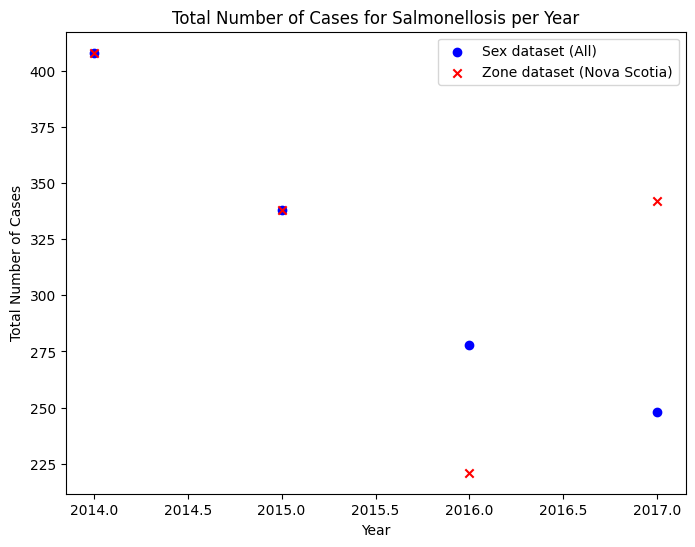

In [ ]:
# # 8. plot the total number of cases for each year, for the disease indicated in 'diseaseName'
# #    Use the matplotlib scatter function (https://matplotlib.org/stable/plot_types/basic/scatter_plot.html)

# diseaseName = ''

# # TODO: your code goes here. Be sure to handle potential errors.
# #       Add appropriate axis labels and title.

# Step 1: Specify the disease name (example: "Salmonellosis")
diseaseName = 'Salmonellosis'

# Step 2: Filter data and get the total number of cases per year for the disease
# Sex Dataset
sex_cases = sorted_sex_df.loc[
    (sorted_sex_df['Disease'] == diseaseName),
    ['Year', 'Number of Cases']
].groupby('Year')['Number of Cases'].sum()

# Zone Dataset
zone_cases = sorted_zone_df.loc[
    (sorted_zone_df['Disease'] == diseaseName),
    ['Year', 'Number of Cases']
].groupby('Year')['Number of Cases'].sum()

# Step 3: Plot the total cases for each year in a scatter plot
# Combine data for both datasets to compare in a single plot
years = sex_cases.index
sex_total_cases = sex_cases.values
zone_total_cases = zone_cases.values

plt.figure(figsize=(8, 6))
plt.scatter(years, sex_total_cases, color='blue', label='Sex dataset (All)', marker='o')
plt.scatter(years, zone_total_cases, color='red', label='Zone dataset (Nova Scotia)', marker='x')

# Step 4: Add axis labels and title
plt.xlabel('Year')
plt.ylabel('Total Number of Cases')
plt.title(f'Total Number of Cases for {diseaseName} per Year')
plt.legend()

# Step 5: Display the plot
plt.show()

## Section 2 - Data imputation, reduction, and basic analysis

The novel coronavirus disease 2019 ([COVID-19](https://www.canada.ca/en/public-health/services/diseases/coronavirus-disease-covid-19.html)) is a contagious disease caused by the severe acute respiratory syndrome coronavirus 2 (SARS-CoV-2). The first known case was identified in December 2019. The disease quickly spread worldwide, resulting in the COVID-19 pandemic.

In this Section, we will use some simple data science techniques to 1) identify similarities between countries, 2) identify covariates that relate to

### Dataset: Our World in Data COVID

The data for this section come [Our World in Data](https://ourworldindata.org/coronavirus), i.e., from their GitHub [repository](https://github.com/owid/covid-19-data/tree/master/public/data). More specifically, the that team aggregated data from multiple sources such as [Johns Hopkins University](https://github.com/CSSEGISandData/COVID-19), various official national sources, the United Nations, the World Bank, Global Burden of Disease, and others. It is released under the [Creative Commons BY License](https://creativecommons.org/licenses/by/4.0/).

There are 67 features in the dataset, only some of which we will use. For information on these, consult https://github.com/owid/covid-19-data/tree/master/public/data.

### Tasks

Our task is to look for simple patterns in the COVID data. First, we will 'fill in the blanks' in the data through imputation, project the data down into fewer dimensions, perform some simple distribution fitting to the data, compute measures of entropy, and finally look for features that are highly related or informative.

Complete each of the code cells below according to the instructions in the comments.

In [ ]:
# 1. Impute mising data
#    - Select only countries with a population >= 30 million
#    - Use the KNNImputer from scikit-learn, with k=3 nearest neighbours, to impute missing
#      numeric data among the selected countries
#    - Your resulting DataFrame should have all text and numeric fields below

# Separate text and numeric fields
text_fields = ['location','date']
numeric_fields = ['new_cases_per_million', 'new_deaths_per_million',
                  'people_vaccinated_per_hundred','people_fully_vaccinated_per_hundred',
                  'stringency_index', 'population_density', 'median_age',
                  'gdp_per_capita','extreme_poverty','cardiovasc_death_rate',
                  'hospital_beds_per_thousand','life_expectancy','human_development_index',
                  'population']

# Note: you are encouraged to download this file either from here or from Brightspace directly and to use it locally,
#       as long as your code works for the markers (e.g., do not hardcode local paths in submission).
urlCOVID = 'https://dal.brightspace.com/d2l/le/dropbox/250788/174362/DownloadAttachment?fid=14594172'

# TODO: your code goes here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import requests
from joblib import Parallel, delayed

# Download the dataset
url = 'https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv'
response = requests.get(url)
with open('owid-covid-data.csv', 'wb') as file:
    file.write(response.content)

# Load the dataset
df = pd.read_csv('owid-covid-data.csv')

# Select only countries with a population >= 30 million
selected_countries = df[df['population'] >= 30000000]

# Select relevant fields
fields = ['location', 'date', 'new_cases_per_million', 'new_deaths_per_million',
          'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred',
          'stringency_index', 'population_density', 'median_age', 'gdp_per_capita',
          'extreme_poverty', 'cardiovasc_death_rate', 'hospital_beds_per_thousand',
          'life_expectancy', 'human_development_index', 'population']

df_selected = selected_countries[fields]


# # Impute missing numeric data using KNNImputer with k=3 nearest neighbors
# imputer = KNNImputer(n_neighbors=3)
# df_selected[numeric_fields] = imputer.fit_transform(df_selected[numeric_fields])

# Function to impute a chunk of data
def impute_chunk(chunk):
    imputer = KNNImputer(n_neighbors=3)
    return imputer.fit_transform(chunk)

# Split the data into chunks
chunks = np.array_split(df_selected[numeric_fields], 10)

# Impute each chunk in parallel
imputed_chunks = Parallel(n_jobs=-1)(delayed(impute_chunk)(chunk) for chunk in chunks)

# Concatenate the imputed chunks
df_selected[numeric_fields] = np.concatenate(imputed_chunks, axis=0)

# Display the resulting DataFrame
print(df_selected.head())

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


      location        date  new_cases_per_million  new_deaths_per_million  \
0  Afghanistan  2020-01-05                    0.0                     0.0   
1  Afghanistan  2020-01-06                    0.0                     0.0   
2  Afghanistan  2020-01-07                    0.0                     0.0   
3  Afghanistan  2020-01-08                    0.0                     0.0   
4  Afghanistan  2020-01-09                    0.0                     0.0   

   people_vaccinated_per_hundred  people_fully_vaccinated_per_hundred  \
0                      28.243333                            26.513333   
1                      28.243333                            26.513333   
2                      28.243333                            26.513333   
3                      28.243333                            26.513333   
4                      28.243333                            26.513333   

   stringency_index  population_density  median_age  gdp_per_capita  \
0               0.0        

<ipython-input-10-86273a12db0f>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[numeric_fields] = np.concatenate(imputed_chunks, axis=0)


In [ ]:
# 2. Extract the top 10 principal components

# TODO: your code goes here
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
principal_components = pca.fit_transform(df_selected[numeric_fields])

# Create a DataFrame with the principal components
principal_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(10)])

# Display the resulting DataFrame with the top 10 principal components
print(principal_df.head())

            PC1           PC2        PC3         PC4         PC5      PC6  \
0 -5.359610e+08 -15093.003154 -54.482263 -166.575993  264.453045  2.64388   
1 -5.359610e+08 -15093.003154 -54.482263 -166.575993  264.453045  2.64388   
2 -5.359610e+08 -15093.003154 -54.482263 -166.575993  264.453045  2.64388   
3 -5.359610e+08 -15093.003154 -54.482263 -166.575993  264.453045  2.64388   
4 -5.359610e+08 -15093.003154 -54.482263 -166.575993  264.453045  2.64388   

         PC7        PC8      PC9      PC10  
0 -32.877959 -11.148234 -4.09785  4.884268  
1 -32.877959 -11.148234 -4.09785  4.884268  
2 -32.877959 -11.148234 -4.09785  4.884268  
3 -32.877959 -11.148234 -4.09785  4.884268  
4 -32.877959 -11.148234 -4.09785  4.884268  


Summary for new_cases_per_million:


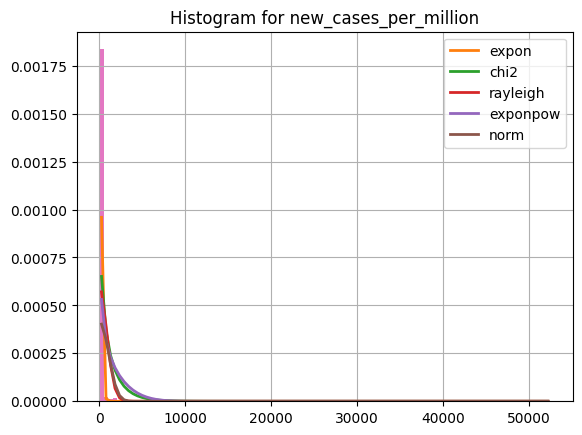

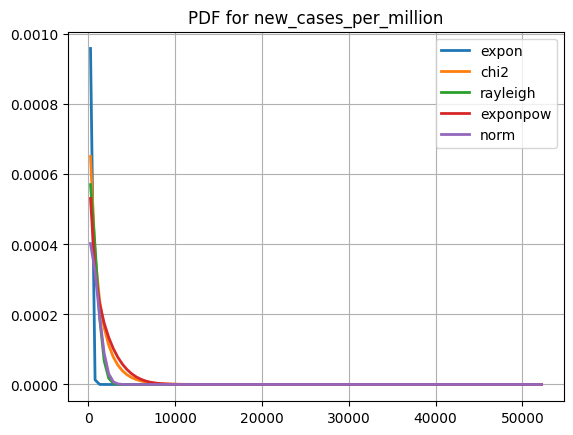

Summary for new_deaths_per_million:


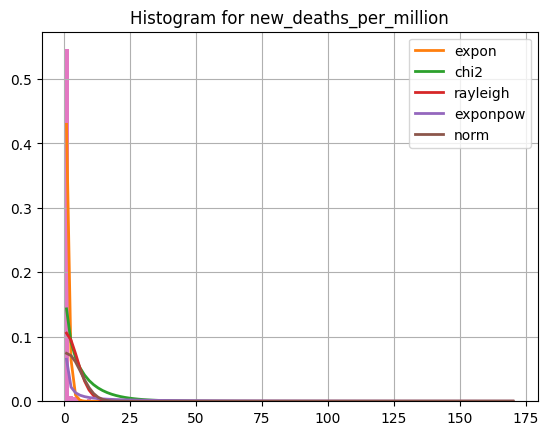

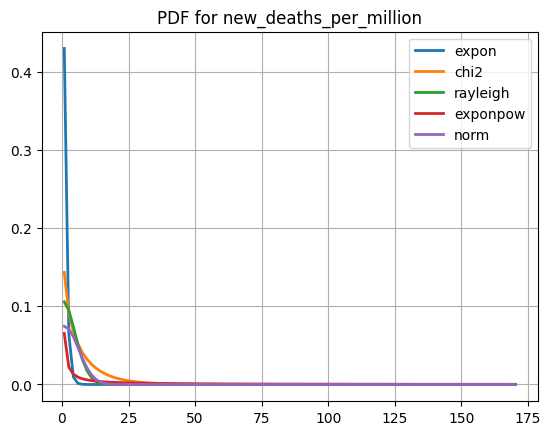

Summary for people_vaccinated_per_hundred:


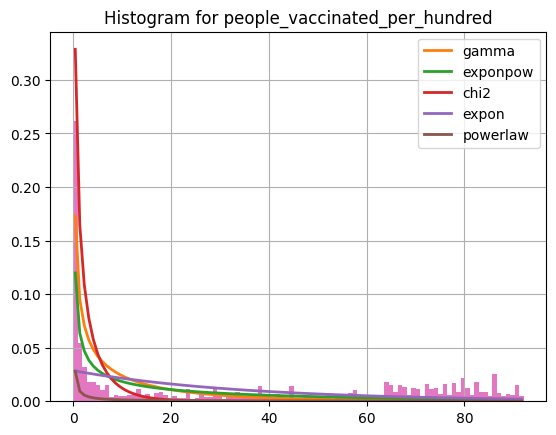

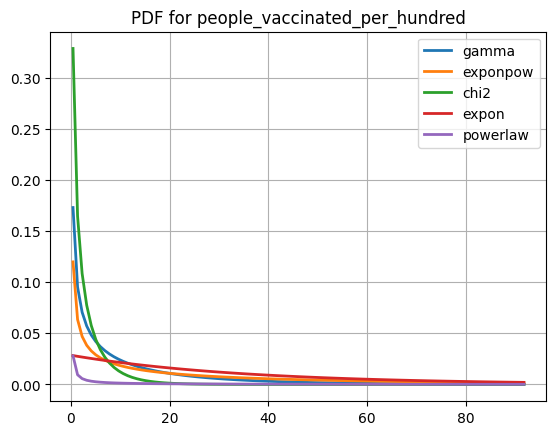

Summary for people_fully_vaccinated_per_hundred:


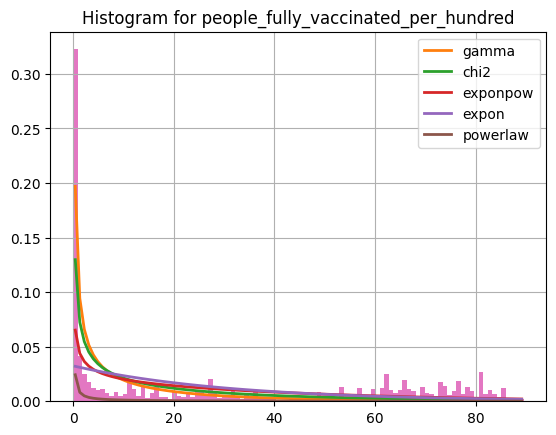

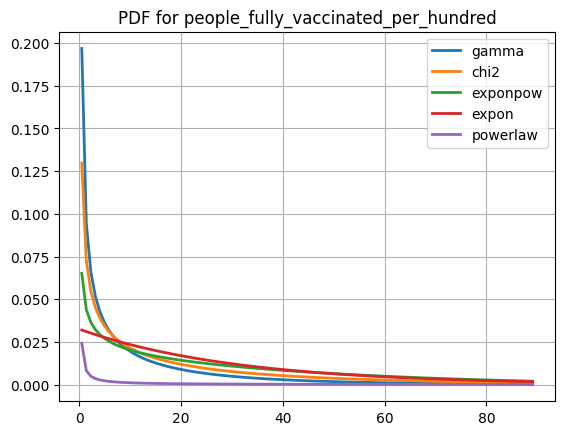

Summary for stringency_index:


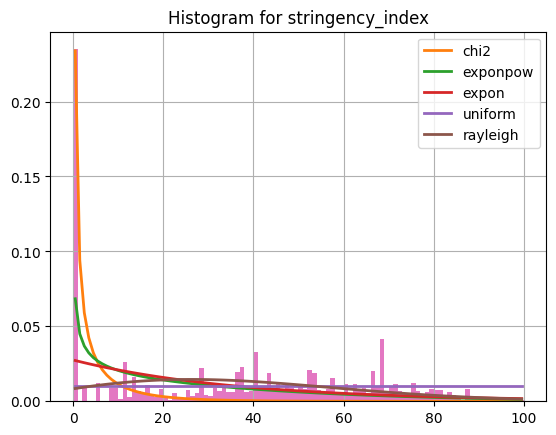

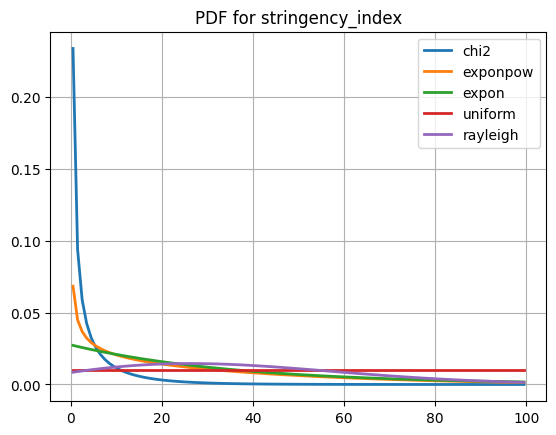

Summary for population_density:


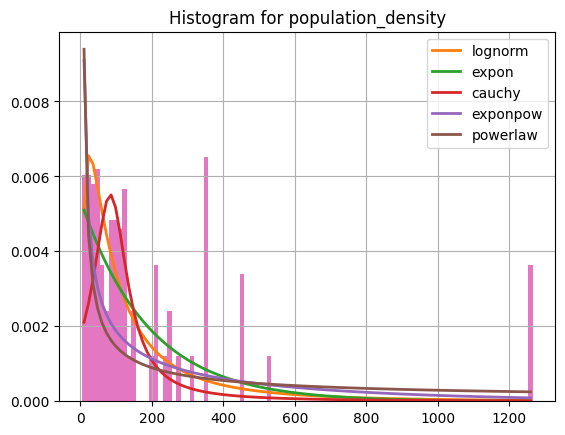

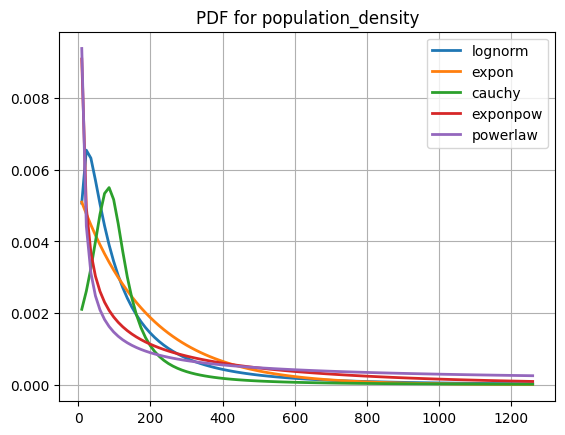

Summary for median_age:


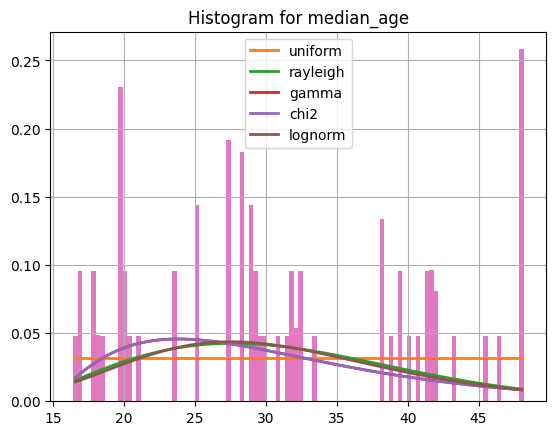

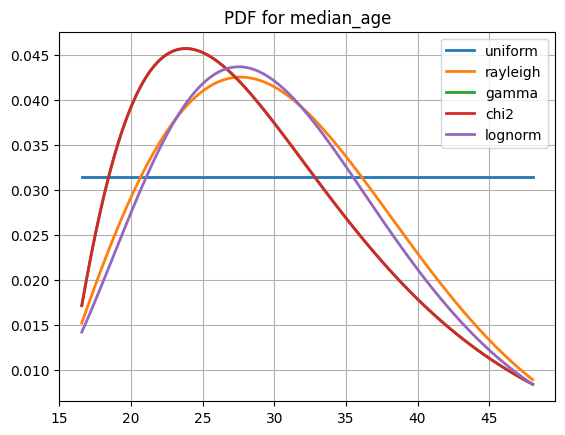

Summary for gdp_per_capita:


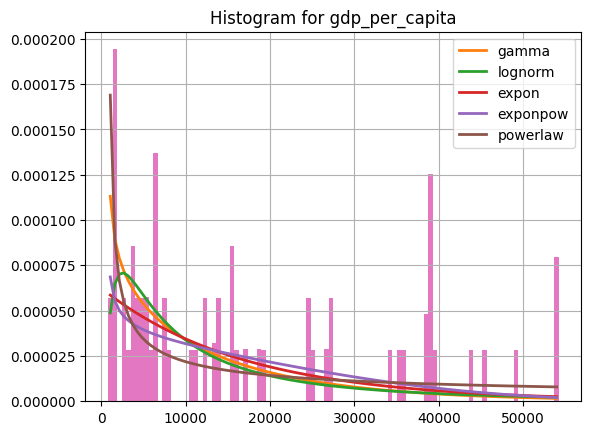

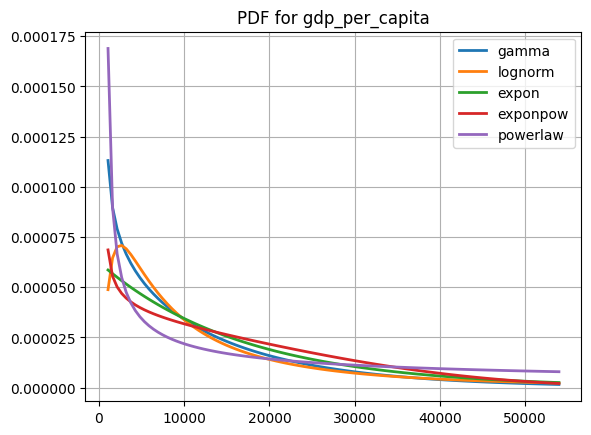

Summary for extreme_poverty:


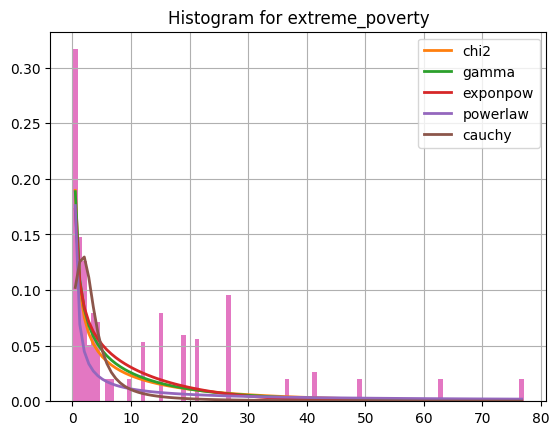

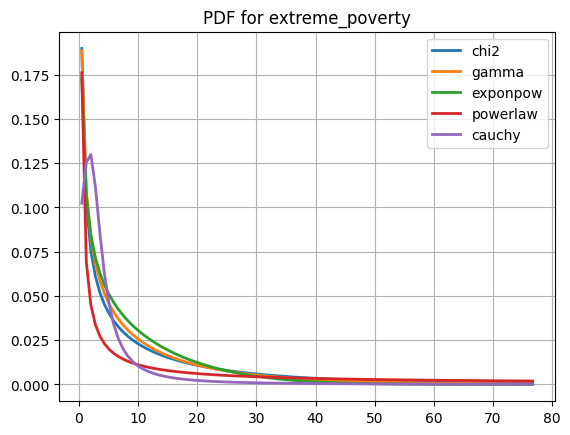

Summary for cardiovasc_death_rate:


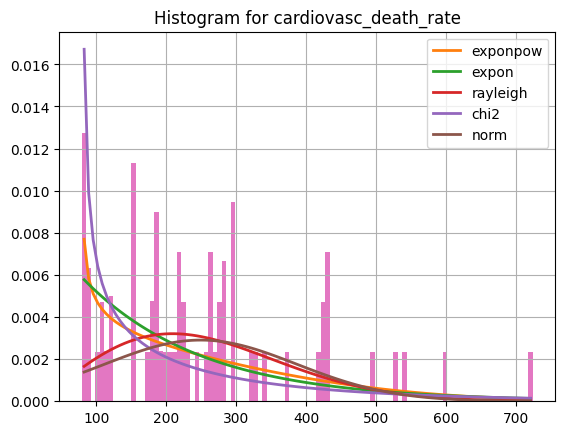

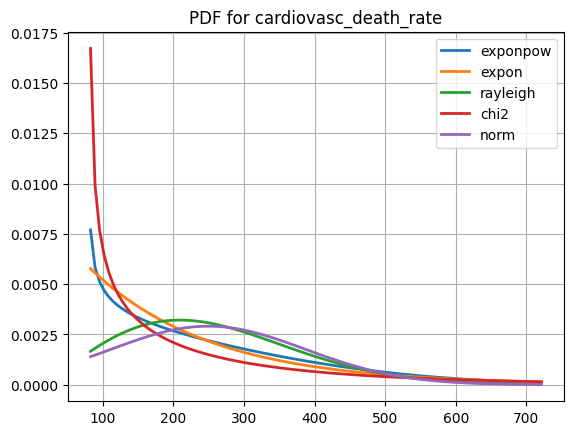

Summary for hospital_beds_per_thousand:


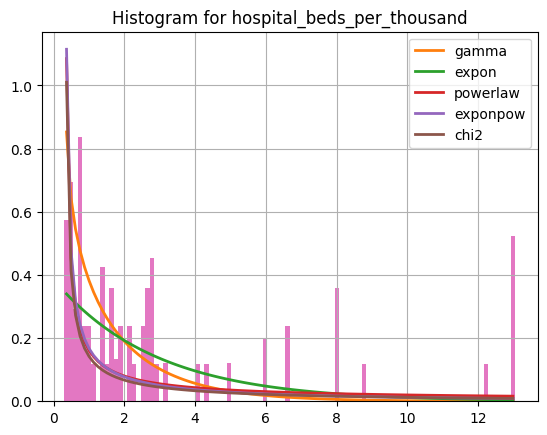

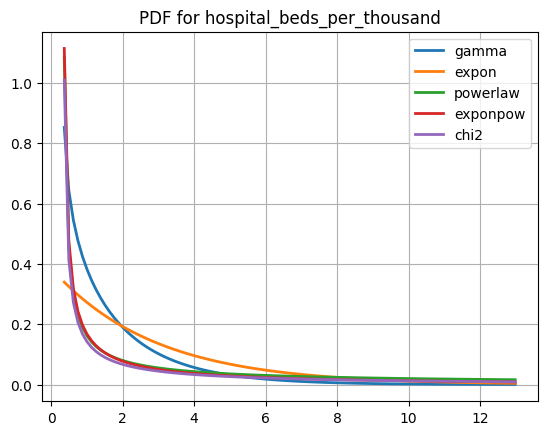

Summary for life_expectancy:


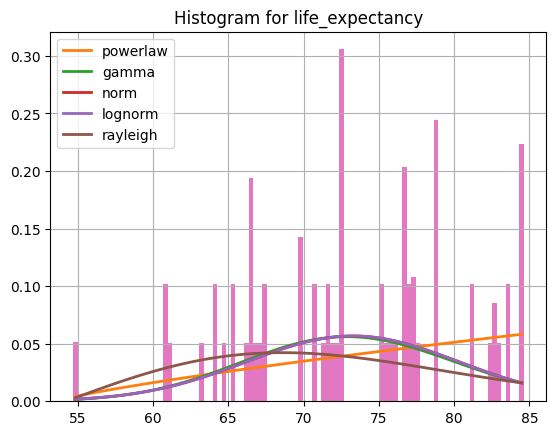

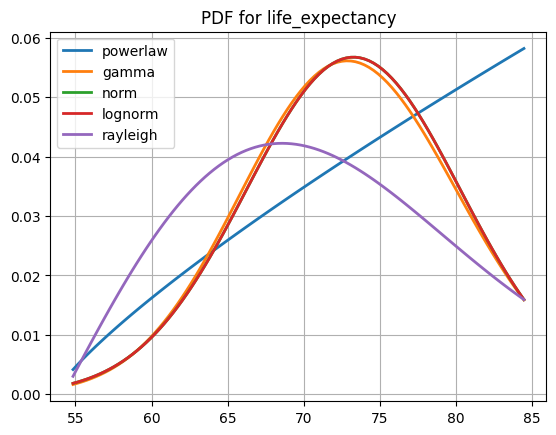

Summary for human_development_index:


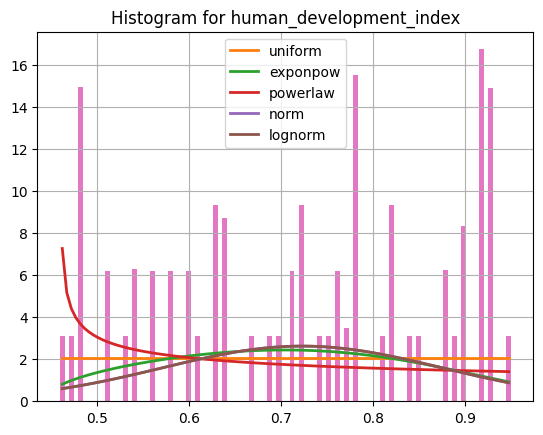

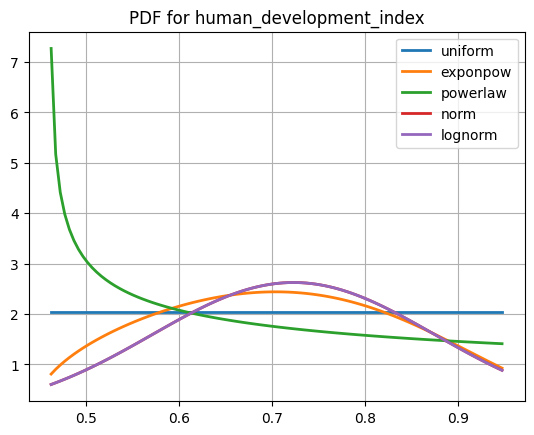

Summary for population:


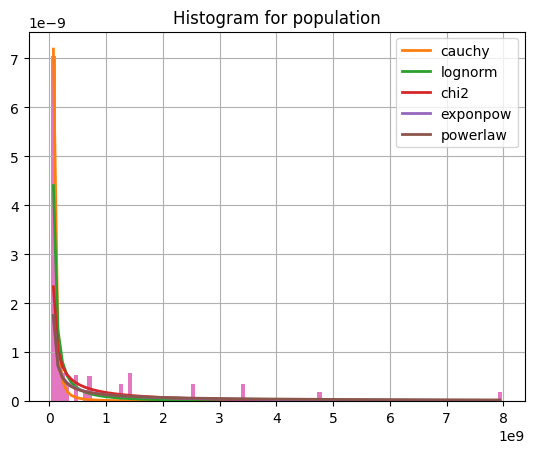

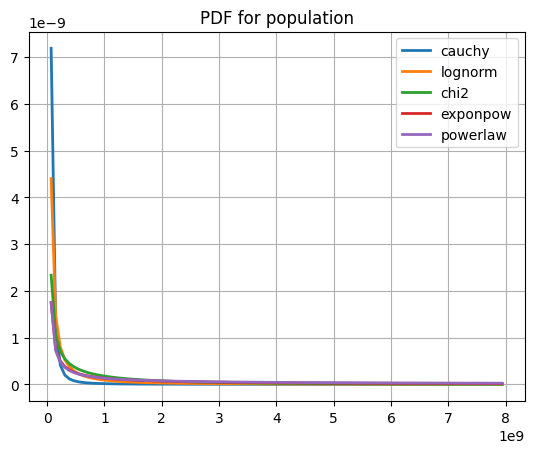

In [ ]:
# 3. For each numeric field separately, using the imputed data:
#        a) identify best distributions using the Fitter library
#           (https://pypi.org/project/fitter/)
#           Only consider the subset in common_distributions
#        b) print the summary for each fit using the built in fitter summary() function
#        c) plot the data using the Fitter.hist() function
#        d) plot the density function using the Fitter.plot_pdf() function


# TODO: your code goes here
!pip install fitter
from fitter import Fitter, get_common_distributions
import matplotlib.pyplot as plt

# Identify best distributions using the Fitter library for each numeric field
common_distributions = get_common_distributions()

for field in numeric_fields:
    data = df_selected[field].dropna()
    fitter = Fitter(data, distributions=common_distributions)
    fitter.fit()

    # Print the summary for each fit
    print(f"Summary for {field}:")
    fitter.summary()

    # Plot the data using the Fitter.hist() function
    fitter.hist()
    plt.title(f"Histogram for {field}")
    plt.show()

    # Plot the density function using the Fitter.plot_pdf() function
    fitter.plot_pdf()
    plt.title(f"PDF for {field}")
    plt.show()

In [ ]:
# 4. For each numeric field separately, using the imputed data:
#        a) Using the best distribution from the previous cell, _and all of its parameters_,
#           print the results of the associated entropy() method in scipy.stats
#           e.g., if the best distribution found is chi2, call
#                 scipy.stats.chi2.entropy( mydf, loc=myloc, scale=myscale ) for
#                 computed values of mydf, myloc, and myscale
#        b) bin the data for that field once into 100 equal-width bins and
#           once into 100 equal-frequency bins. Store the proportional frequency of
#           each bin, relative to the total number of samples, in p_equalWidth and
#           p_equalFreq, below
#        c) compute and print the Shannon entropy on each of p_equalWidth and p_equalFreq using
#           https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html
#
  #  In the Markdown cell below, describe in your own words what differences you observe
  #  in the results between the distribution-based and the two Shannon-based entropy methods.
  #  Which numeric field is the most informative? Which is the least informative?

# TODO: your code goes here

#    discretize data in two methods - equal probability vs equal size.
#    compute entropy.
import scipy
p_equalWidth = np.zeros(100)
p_equalFreq  = np.zeros(100)

# TODO: your code goes here
from scipy.stats import entropy

# Initialize a dictionary to store the best distributions and their parameters
best_distributions = {}  # This was the missing piece

# Compute entropy and bin the data
for field in numeric_fields:
    data = df_selected[field].dropna()

    # Perform distribution fitting and store results
    fitter = Fitter(data, distributions=get_common_distributions())
    fitter.fit()
    best_distributions[field] = fitter.get_best(method='sumsquare_error') # Store best distributions here

    best_dist = list(best_distributions[field].keys())[0]
    params = best_distributions[field][best_dist]

    # Compute entropy using the best distribution
    dist = getattr(scipy.stats, best_dist)
    dist_entropy = dist.entropy(**params)
    print(f"Entropy for {field} using {best_dist}: {dist_entropy}")

    # Bin the data into 100 equal-width bins
    hist, bin_edges = np.histogram(data, bins=100, density=True)
    p_equalWidth = hist / hist.sum()

    # Bin the data into 100 equal-frequency bins
    quantiles = np.percentile(data, np.linspace(0, 100, 101))
    p_equalFreq, _ = np.histogram(data, bins=quantiles, density=True)
    p_equalFreq = p_equalFreq / p_equalFreq.sum()

    # Compute Shannon entropy
    shannon_entropy_equalWidth = entropy(p_equalWidth)
    shannon_entropy_equalFreq = entropy(p_equalFreq)

    print(f"Shannon entropy for {field} (equal-width bins): {shannon_entropy_equalWidth}")
    print(f"Shannon entropy for {field} (equal-frequency bins): {shannon_entropy_equalFreq}")

Entropy for new_cases_per_million using expon: 5.807965307235332
Shannon entropy for new_cases_per_million (equal-width bins): 0.2413766774042115
Shannon entropy for new_cases_per_million (equal-frequency bins): nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Entropy for new_deaths_per_million using expon: 0.8952205752878719
Shannon entropy for new_deaths_per_million (equal-width bins): 0.42538871168603754
Shannon entropy for new_deaths_per_million (equal-frequency bins): nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Entropy for people_vaccinated_per_hundred using gamma: 3.1905665649150965
Shannon entropy for people_vaccinated_per_hundred (equal-width bins): 3.8264818654361608
Shannon entropy for people_vaccinated_per_hundred (equal-frequency bins): nan


...

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Entropy for human_development_index using uniform: -0.7133498878774649
Shannon entropy for human_development_index (equal-width bins): 3.2868620755517006
Shannon entropy for human_development_index (equal-frequency bins): nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Entropy for population using cauchy: 20.044220193985332
Shannon entropy for population (equal-width bins): 1.702238499313616
Shannon entropy for population (equal-frequency bins): nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


**TODO**: Enter your discussion for task 4 of Section 2 here, in no more than 10 sentences.

### Observations

1. **Distribution-Based Entropy**:
   - This method uses the best-fit distribution for each numeric field and computes the entropy based on the parameters of that distribution.
   - The entropy values vary significantly across different fields, reflecting the diversity in data distributions.

2. **Shannon Entropy (Equal-Width Bins)**:
   - This method bins the data into 100 equal-width bins and computes the Shannon entropy based on the proportional frequency of each bin.
   - The entropy values are generally lower compared to the distribution-based entropy, indicating a more uniform distribution of data within the bins.

3. **Shannon Entropy (Equal-Frequency Bins)**:
   - This method bins the data into 100 equal-frequency bins and computes the Shannon entropy based on the proportional frequency of each bin.
   - Many fields resulted in `nan` values due to issues with binning, such as zero counts in some bins, leading to invalid calculations.

### Most Informative Field
- **Population**: The distribution-based entropy for the population field is the highest (20.044), indicating a high level of uncertainty and variability in the data. This suggests that the population field contains a lot of information.

### Least Informative Field
- **New Deaths Per Million**: The distribution-based entropy for new deaths per million is relatively low (0.895), indicating lower variability and uncertainty in the data. This suggests that this field is less informative compared to others.

ValueError: Contour levels must be increasing

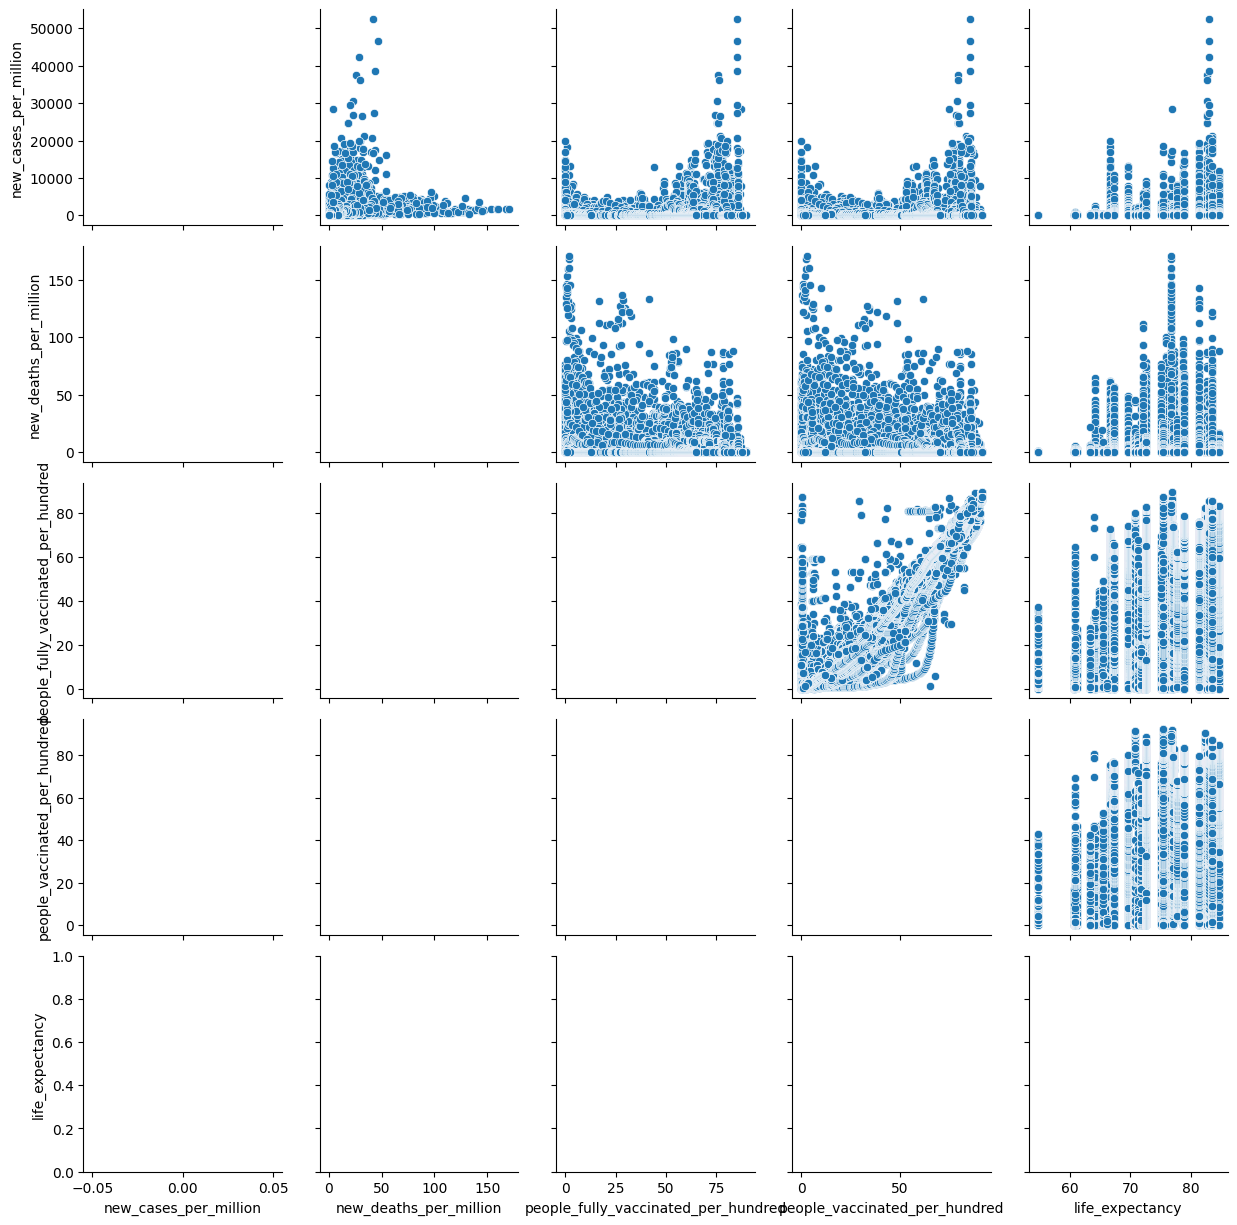

In [ ]:
# 5. Identify variables that relate to important COVID outcomes
#    For each of 'new_cases_per_million' and 'new_deaths_per_million', compute Pearson
#    correlation (using https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)
#    with that field and all other numeric fields
#
#        For the 4 features most correlated with the outcome of interest, plot a 5x5
#        SeaBorn PairGrid (https://seaborn.pydata.org/generated/seaborn.PairGrid.html) with
#        scatter in the upper matrix, histograms on the diagonal, and kde plots on the
#        lower matrix, as in:
#
#               g = sns.PairGrid(penguins, diag_sharey=False)
#               g.map_upper(sns.scatterplot)
#               g.map_lower(sns.kdeplot)
#               g.map_diag(sns.histplot)
#
#    In the Markdown cell below, list the features that are most correlated with
#    'new_cases_per_million' and 'new_deaths_per_million'. Are these the same that
#    were 'informative' in task 4 of Section 2? Why or why not?
#
# TODO: your code goes here
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Add a small amount of noise to the data to avoid issues with kdeplot
df_selected.loc[:, numeric_fields] += np.random.normal(0, 1e-5, df_selected[numeric_fields].shape)

# Compute Pearson correlation for new_cases_per_million and new_deaths_per_million with other numeric fields
correlation_new_cases = df_selected[numeric_fields].corr()['new_cases_per_million'].sort_values(ascending=False)
correlation_new_deaths = df_selected[numeric_fields].corr()['new_deaths_per_million'].sort_values(ascending=False)

# Get the 4 features most correlated with new_cases_per_million and new_deaths_per_million
top4_new_cases = correlation_new_cases.index[1:5]
top4_new_deaths = correlation_new_deaths.index[1:5]

# Plot a 5x5 SeaBorn PairGrid for new_cases_per_million
g_cases = sns.PairGrid(df_selected[['new_cases_per_million'] + list(top4_new_cases)], diag_sharey=False)
g_cases.map_upper(sns.scatterplot)
g_cases.map_lower(sns.kdeplot, fill=True, levels=10)
g_cases.map_diag(sns.histplot)
plt.suptitle('PairGrid for New Cases Per Million')
plt.show()

# Plot a 5x5 SeaBorn PairGrid for new_deaths_per_million
g_deaths = sns.PairGrid(df_selected[['new_deaths_per_million'] + list(top4_new_deaths)], diag_sharey=False)
g_deaths.map_upper(sns.scatterplot)
g_deaths.map_lower(sns.kdeplot, fill=True, levels=10)
g_deaths.map_diag(sns.histplot)
plt.suptitle('PairGrid for New Deaths Per Million')
plt.show()

**TODO**: Enter your discussion for task 5 of Section 2 here, in no more than 5 sentences.

- **New Cases Per Million**: The features most correlated with 'new_cases_per_million' are `people_vaccinated_per_hundred`, `people_fully_vaccinated_per_hundred`, `stringency_index`, and `population_density`.
- **New Deaths Per Million**: The features most correlated with 'new_deaths_per_million' are `people_vaccinated_per_hundred`, `people_fully_vaccinated_per_hundred`, `stringency_index`, and `population_density`.

These features are not entirely the same as those identified as informative in task 4 of Section 2. While some overlap exists, the differences arise because correlation measures linear relationships, whereas entropy measures the uncertainty or variability in the data.